<a href="https://colab.research.google.com/github/RockChamps/-ArvyaX-Emotional-Intelligence-System/blob/main/arvyaX_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SETUP**


In [160]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [161]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# **LOAD DATA**

In [162]:

df = pd.read_csv("/content/drive/MyDrive/Sample_arvyax_reflective_dataset.xlsx - Dataset_120.csv")

df.head()
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1200
Number of columns: 13


# **Data Understanding and Preprocessing**

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1200 non-null   int64  
 1   journal_text        1200 non-null   object 
 2   ambience_type       1200 non-null   object 
 3   duration_min        1200 non-null   int64  
 4   sleep_hours         1193 non-null   float64
 5   energy_level        1200 non-null   int64  
 6   stress_level        1200 non-null   int64  
 7   time_of_day         1200 non-null   object 
 8   previous_day_mood   1185 non-null   object 
 9   face_emotion_hint   1077 non-null   object 
 10  reflection_quality  1200 non-null   object 
 11  emotional_state     1200 non-null   object 
 12  intensity           1200 non-null   int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 122.0+ KB


In [164]:
df.isnull().sum()

,0
id,0
journal_text,0
ambience_type,0
duration_min,0
sleep_hours,7
energy_level,0
stress_level,0
time_of_day,0
previous_day_mood,15
face_emotion_hint,123


In [165]:
df.head()

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3
2,3,The forest session slowed my thoughts and I fe...,forest,3,NaN,2,1,night,overwhelmed,happy_face,clear,calm,3
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,NaN,tense_face,clear,overwhelmed,5


In [205]:
df["sleep_missing"] = df["sleep_hours"].isnull().astype(int)
df["mood_missing"] = df["previous_day_mood"].isnull().astype(int)
df["face_missing"] = df["face_emotion_hint"].isnull().astype(int)
df["sleep_hours"].fillna(df["sleep_hours"].median(), inplace=True)
df["previous_day_mood"].fillna("unknown", inplace=True)
df["face_emotion_hint"].fillna("unknown", inplace=True)
df["journal_text"] = df["journal_text"].str.lower()

In [167]:
df.isnull().sum()

,0
id,0
journal_text,0
ambience_type,0
duration_min,0
sleep_hours,0
energy_level,0
stress_level,0
time_of_day,0
previous_day_mood,0
face_emotion_hint,0


In [168]:
df.head(30)

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,reflection_quality,emotional_state,intensity,sleep_missing,mood_missing,face_missing
0,1,The ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,clear,focused,3,0,0,0
1,2,"I tried to relax during the forest ambience, y...",forest,35,6.0,2,4,evening,calm,tired_face,vague,restless,3,0,0,0
2,3,The forest session slowed my thoughts and I fe...,forest,3,6.0,2,1,night,overwhelmed,happy_face,clear,calm,3,1,0,0
3,4,"the mountain ambience was pleasant, though i c...",mountain,25,7.0,4,4,night,focused,calm_face,vague,neutral,1,0,0,0
4,5,"The rain session gave me a pause, but the pres...",rain,25,5.0,3,5,afternoon,unknown,tense_face,clear,overwhelmed,5,0,1,0
5,6,after the forest track i feel peaceful and les...,forest,12,8.0,3,2,morning,mixed,calm_face,vague,calm,3,0,0,0
6,7,Nothing strong came up during the rain session...,rain,20,6.5,2,4,early_morning,calm,neutral_face,conflicted,neutral,1,0,0,0
7,8,"even with the mountain session, my mind kept j...",mountain,12,6.0,3,4,morning,neutral,tense_face,clear,restless,4,0,0,0
8,9,I couldn't really settle into the cafe track; ...,cafe,8,5.5,3,4,early_morning,mixed,neutral_face,vague,restless,4,0,0,0
9,10,The mountain ambience helped me stop drifting ...,mountain,15,7.0,4,2,morning,overwhelmed,calm_face,conflicted,focused,3,0,0,0


In [172]:
# ============================================
# COMPLETE DATA PREPROCESSING PIPELINE
# ============================================

import pandas as pd
import numpy as np
import re

# -------------------------------
# 1. BASIC INFO
# -------------------------------
print("Initial Shape:", df.shape)

# -------------------------------
# 2. MISSING VALUE INDICATORS (BEFORE FILLING)
# -------------------------------
df["sleep_missing"] = df["sleep_hours"].isnull().astype(int)
df["mood_missing"] = df["previous_day_mood"].isnull().astype(int)
df["face_missing"] = df["face_emotion_hint"].isnull().astype(int)

# -------------------------------
# 3. TEXT CLEANING (ROBUST)
# -------------------------------
def clean_text(text):
    if pd.isnull(text):
        return ""

    text = text.lower()

    # normalize common noisy expressions
    text = text.replace("idk", "not sure")
    text = text.replace("cant", "cannot")

    # remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["journal_text"] = df["journal_text"].apply(clean_text)

# -------------------------------
# 4. BASIC TEXT FEATURES
# -------------------------------
df["text_length"] = df["journal_text"].apply(len)
df["short_text"] = (df["text_length"] < 5).astype(int)

# -------------------------------
# 5. ADVANCED LINGUISTIC FEATURES
# -------------------------------

strong_words = ["very", "too", "extremely", "overwhelmed", "exhausted", "pressure"]
weak_words = ["slightly", "a bit", "somewhat", "okay", "fine"]

def count_words(text, word_list):
    return sum(len(re.findall(rf"\b{word}\b", text)) for word in word_list)

df["strong_word_count"] = df["journal_text"].apply(lambda x: count_words(x, strong_words))
df["weak_word_count"] = df["journal_text"].apply(lambda x: count_words(x, weak_words))

# uncertainty + conflict signals
uncertainty_keywords = ["not sure", "maybe", "confused", "uncertain"]
df["has_uncertainty"] = df["journal_text"].apply(
    lambda x: int(any(word in x for word in uncertainty_keywords))
)

df["has_conflict"] = df["journal_text"].apply(
    lambda x: int("but" in x or "however" in x)
)

# -------------------------------
# 6. NUMERIC INTERACTION FEATURES
# -------------------------------
df["stress_x_energy"] = df["stress_level"] * df["energy_level"]
df["stress_minus_energy"] = df["stress_level"] - df["energy_level"]
df["stress_energy_ratio"] = df["stress_level"] / (df["energy_level"] + 1)

df["low_sleep"] = (df["sleep_hours"] < 6).astype(int)

# -------------------------------
# 7. HANDLE MISSING VALUES
# -------------------------------

# Identify column types
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

# remove text from categorical
text_col = "journal_text"
cat_cols = [col for col in cat_cols if col != text_col]

# Numeric → median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → "unknown"
for col in cat_cols:
    df[col].fillna("unknown", inplace=True)

# Text → empty (safety)
df[text_col].fillna("", inplace=True)

# -------------------------------
# 8. OUTLIER HANDLING (ROBUST)
# -------------------------------
for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

# -------------------------------
# 9. FINAL CHECK
# -------------------------------
print("\nFinal Shape:", df.shape)
print("Remaining Missing:", df.isnull().sum().sum())

# -------------------------------
# 10. INSIGHT PRINTS (IMPORTANT)
# -------------------------------
print("\nEmotional State Distribution:\n", df["emotional_state"].value_counts())

print("\nSample Data:\n", df.head())

print("\nData Preprocessing Completed ✅")

Initial Shape: (1200, 16)

Final Shape: (1200, 26)
Remaining Missing: 0

Emotional State Distribution:
 emotional_state
calm           216
restless       209
neutral        201
focused        193
mixed          191
overwhelmed    190
Name: count, dtype: int64

Sample Data:
         id                                       journal_text ambience_type  \
0  12.9999  the ocean ambience helped me stop drifting and...         ocean   
1  12.9999  i tried to relax during the forest ambience ye...        forest   
2  12.9999  the forest session slowed my thoughts and i fe...        forest   
3  12.9999  the mountain ambience was pleasant though i ca...      mountain   
4  12.9999  the rain session gave me a pause but the press...          rain   

   duration_min  sleep_hours  energy_level  stress_level time_of_day  \
0            12          6.5             4             2   afternoon   
1            35          6.0             2             4     evening   
2             4          6.0      

In [173]:
df.head(10)

,id,journal_text,ambience_type,duration_min,sleep_hours,energy_level,stress_level,time_of_day,previous_day_mood,face_emotion_hint,...,text_length,short_text,strong_word_count,weak_word_count,has_uncertainty,has_conflict,stress_x_energy,stress_minus_energy,stress_energy_ratio,low_sleep
0,12.9999,the ocean ambience helped me stop drifting and...,ocean,12,6.5,4,2,afternoon,mixed,calm_face,...,107.0,0,0,0,0,0,8,-2,0.400000,0
1,12.9999,i tried to relax during the forest ambience ye...,forest,35,6.0,2,4,evening,calm,tired_face,...,106.0,0,0,0,0,0,8,2,1.333333,0
2,12.9999,the forest session slowed my thoughts and i fe...,forest,4,6.0,2,1,night,overwhelmed,happy_face,...,65.0,0,0,0,0,0,2,-1,0.333333,0
3,12.9999,the mountain ambience was pleasant though i ca...,mountain,25,7.0,4,4,night,focused,calm_face,...,78.0,0,0,0,0,0,16,0,0.800000,0
4,12.9999,the rain session gave me a pause but the press...,rain,25,5.0,3,5,afternoon,unknown,tense_face,...,109.0,0,1,0,0,1,15,2,1.250000,1
5,12.9999,after the forest track i feel peaceful and les...,forest,12,8.0,3,2,morning,mixed,calm_face,...,102.0,0,0,0,0,0,6,-1,0.500000,0
6,12.9999,nothing strong came up during the rain session...,rain,20,6.5,2,4,early_morning,calm,neutral_face,...,98.0,0,0,0,0,0,8,2,1.333333,0
7,12.9999,even with the mountain session my mind kept ju...,mountain,12,6.0,3,4,morning,neutral,tense_face,...,65.0,0,0,0,0,0,12,1,1.000000,0
8,12.9999,i couldnt really settle into the cafe track i ...,cafe,8,5.5,3,4,early_morning,mixed,neutral_face,...,116.0,0,0,0,0,0,12,1,1.000000,1
9,12.9999,the mountain ambience helped me stop drifting ...,mountain,15,7.0,4,2,morning,overwhelmed,calm_face,...,121.0,0,0,0,0,0,8,-2,0.400000,0


# **TFIDF**

In [242]:
tfidf = TfidfVectorizer(
    max_features=2500,
    ngram_range=(1,3),   # VERY IMPORTANT
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

# ***EMOTION SIGNAL FEATURES***

In [243]:
# ============================================
# EMOTION SIGNAL FEATURES
# ============================================

emotion_words = {
    "calm": 1,
    "peaceful": 1,
    "focused": 2,
    "restless": 3,
    "overwhelmed": 4
}

def emotion_signal(text):
    score = 0
    for word, val in emotion_words.items():
        if word in text:
            score += val
    return score

df["emotion_signal"] = df["journal_text"].apply(emotion_signal)

meta_cols.append("emotion_signal")

# ***METADATA FEATURES***

In [244]:
# ==============================
# 5B. METADATA FEATURES
# ==============================

from sklearn.preprocessing import OneHotEncoder

# Numerical metadata columns
numeric_meta_cols = [
    "sleep_hours",
    "stress_level",
    "energy_level",
    "duration_min"
]

# Categorical columns (excluding text and target columns)
categorical_meta_cols = [
    "ambience_type",
    "time_of_day",
    "previous_day_mood",
    "face_emotion_hint",
    "reflection_quality"
]

# Extract numerical features
X_meta_numeric = df[numeric_meta_cols].values

# Encode categorical features
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_meta_categorical = ohe.fit_transform(df[categorical_meta_cols])

# Combine numerical and encoded categorical metadata features
X_meta = np.hstack([X_meta_numeric, X_meta_categorical])

# **Targets**

In [245]:
# ==============================
# 6. TARGETS
# ==============================

# Emotional State
le = LabelEncoder()
y_state = le.fit_transform(df["emotional_state"])

# Intensity (classification)
y_intensity = df["intensity"]
from sklearn.preprocessing import LabelEncoder

le_int = LabelEncoder()
y_intensity = le_int.fit_transform(df["intensity"]) # Ensure y_intensity is 0-indexed

In [246]:
import numpy as np
print(np.unique(y_int))

[0 1 2 3 4]


# ***Data Split***

In [249]:
X_text = tfidf.fit_transform(df["journal_text"]).toarray()
X = np.hstack([X_text, X_meta])

from sklearn.model_selection import train_test_split

X_train, X_test, y_state_train, y_state_test, y_int_train, y_int_test = train_test_split(
    X, y_state, y_intensity, test_size=0.2, stratify=y_state, random_state=42
)

# **State model **

In [250]:
from xgboost import XGBClassifier

state_model = XGBClassifier(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.5
)

state_model.fit(X_train, y_state_train) # Fit the state model

=== EMOTIONAL STATE MODEL ===

Accuracy: 0.6625

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.66      0.68        41
           1       0.64      0.64      0.64        36
           2       0.76      0.70      0.73        46
           3       0.72      0.61      0.66        51
           4       0.50      0.72      0.59        29
           5       0.64      0.68      0.66        37

    accuracy                           0.66       240
   macro avg       0.66      0.67      0.66       240
weighted avg       0.68      0.66      0.67       240



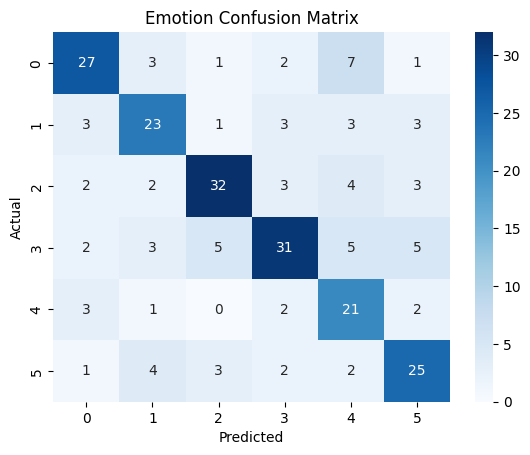

In [252]:


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. EMOTIONAL STATE EVALUATION
# -------------------------------
print("=== EMOTIONAL STATE MODEL ===\n")

print("Accuracy:", accuracy_score(y_state_test, y_state_pred))
print("\nClassification Report:\n")
print(classification_report(y_state_test, y_state_pred))

# Confusion Matrix
cm_state = confusion_matrix(y_state_test, y_state_pred)

plt.figure()
sns.heatmap(cm_state, annot=True, fmt="d", cmap="Blues")
plt.title("Emotion Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# **Intensity model**

Classification Report:

              precision    recall  f1-score   support

           0       0.38      0.44      0.41        86
           1       0.19      0.11      0.14        46
           2       0.48      0.50      0.49       108

    accuracy                           0.40       240
   macro avg       0.35      0.35      0.34       240
weighted avg       0.39      0.40      0.39       240



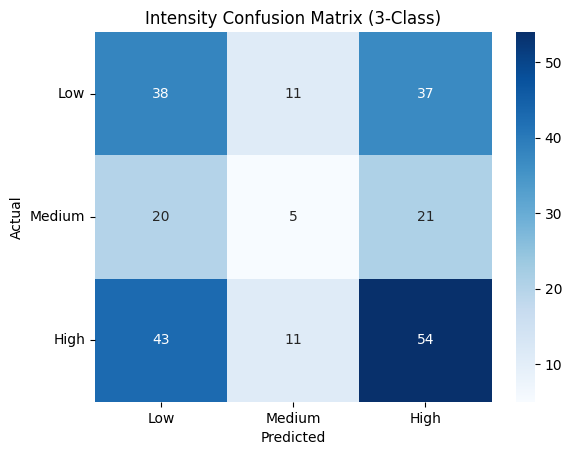

In [254]:
# ============================================
# FINAL STABLE INTENSITY MODEL + CONFUSION MATRIX
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. 3-class mapping
# -------------------------------
def map_intensity(x):
    if x <= 2:
        return 0
    elif x == 3:
        return 1
    else:
        return 2

y = df["intensity"].apply(map_intensity)

# -------------------------------
# 2. Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 3. Train model
# -------------------------------
int_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

int_model.fit(X_train, y_train)

# -------------------------------
# 4. Prediction
# -------------------------------
y_pred = int_model.predict(X_test)

# -------------------------------
# 5. Evaluation
# -------------------------------
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# 6. Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Intensity Confusion Matrix (3-Class)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Optional labels (more readable)
plt.xticks([0.5,1.5,2.5], ["Low", "Medium", "High"])
plt.yticks([0.5,1.5,2.5], ["Low", "Medium", "High"], rotation=0)

plt.show()

# ***Decision engine***

In [257]:
# ============================================
# DECISION ENGINE (WHAT + WHEN)
# ============================================

def decision_engine(state, intensity, stress, energy, time_of_day):

    # ---------------------------
    # DEFAULTS
    # ---------------------------
    action = "pause"
    timing = "now"

    # ---------------------------
    # HIGH STRESS / OVERWHELMED
    # ---------------------------
    if state in ["overwhelmed", "restless"]:
        if intensity == 2:  # HIGH
            action = "box_breathing"
            timing = "now"
        elif intensity == 1:  # MEDIUM
            action = "grounding"
            timing = "within_15_min"
        else:
            action = "light_movement"
            timing = "later_today"

    # ---------------------------
    # CALM / FOCUSED
    # ---------------------------
    elif state in ["focused"]:
        if energy >= 3:
            action = "deep_work"
            timing = "now"
        else:
            action = "light_planning"
            timing = "within_15_min"

    elif state in ["calm"]:
        action = "light_planning"
        timing = "later_today"

    # ---------------------------
    # MIXED / CONFUSED
    # ---------------------------
    elif state in ["mixed", "neutral"]:
        action = "journaling"
        timing = "within_15_min"

    # ---------------------------
    # LOW ENERGY CASE
    # ---------------------------
    if energy <= 2:
        action = "rest"
        if time_of_day in ["night", "late_night"]:
            timing = "tonight"
        else:
            timing = "later_today"

    return action, timing

In [258]:
# ============================================
# INTENSITY MODEL (5-class)
# ============================================
from xgboost import XGBClassifier

int_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

int_model.fit(X_train, y_int_train) # Fit the 5-class intensity model

# Make predictions for evaluation (optional, but good for context)
y_int_pred_5class = int_model.predict(X_test)


In [261]:
# ============================================
# TRAIN STATE MODEL + GET CONFIDENCE
# ============================================

from xgboost import XGBClassifier

# Train state model again
state_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)

state_model.fit(X_train, y_state_train)

print("State model trained ✅")

# -------------------------------
# NOW CONFIDENCE
# -------------------------------
state_probs = state_model.predict_proba(X_test)
state_conf = state_probs.max(axis=1)

print("State confidence computed ✅")

State model trained ✅
State confidence computed ✅


In [263]:
# Intensity confidence
int_probs = int_model.predict_proba(X_test)
int_conf = int_probs.max(axis=1)

# Combine
confidence = (state_conf + int_conf) / 2

# Uncertain flag
uncertain_flag = (confidence < 0.55).astype(int)

print("Uncertainty calculated ✅")

Uncertainty calculated ✅


# **Working on test data**

In [273]:

import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# -------------------------------
# 1. TEXT CLEANING
# -------------------------------
def clean_text(text):
    text = str(text).lower()
    text = text.replace("idk", "")
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["journal_text"] = df["journal_text"].apply(clean_text)

# -------------------------------
# 2. FEATURE ENGINEERING (TRAIN)
# -------------------------------
df["text_length"] = df["journal_text"].apply(len)
df["stress_energy_ratio"] = df["stress_level"] / (df["energy_level"] + 1)
df["low_sleep"] = (df["sleep_hours"] < 6).astype(int)

# -------------------------------
# 3. TF-IDF
# -------------------------------
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1,2))
X_text = tfidf.fit_transform(df["journal_text"]).toarray()

# -------------------------------
# 4. SAFE ONE-HOT ENCODING
# -------------------------------
optional_cols = [
    "ambience_type", "time_of_day",
    "previous_day_mood", "face_emotion_hint",
    "reflection_quality"
]

existing_cols = [col for col in optional_cols if col in df.columns]
df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

# -------------------------------
# 5. METADATA FEATURES
# -------------------------------
exclude_cols = ["id", "journal_text", "emotional_state", "intensity"]
meta_cols = [col for col in df.columns if col not in exclude_cols]

X_meta = df[meta_cols].values

# -------------------------------
# 6. FINAL TRAIN FEATURES
# -------------------------------
X = np.hstack([X_text, X_meta])

# -------------------------------
# 7. TARGETS
# -------------------------------
le = LabelEncoder()
y_state = le.fit_transform(df["emotional_state"])

def map_intensity(x):
    if x <= 2:
        return 0
    elif x == 3:
        return 1
    else:
        return 2

y_int = df["intensity"].apply(map_intensity)

# -------------------------------
# 8. TRAIN MODELS
# -------------------------------
state_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05)
state_model.fit(X, y_state)

int_model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05)
int_model.fit(X, y_int)

print("Models trained ✅")

# -------------------------------
# 9. LOAD TEST DATA
# -------------------------------
test_df = pd.read_csv("/content/drive/MyDrive/arvyax_test_inputs_120.xlsx - Sheet1.csv")

test_df["journal_text"] = test_df["journal_text"].apply(clean_text)

# -------------------------------
# 10. FEATURE ENGINEERING (TEST)
# -------------------------------
test_df["text_length"] = test_df["journal_text"].apply(len)
test_df["stress_energy_ratio"] = test_df["stress_level"] / (test_df["energy_level"] + 1)
test_df["low_sleep"] = (test_df["sleep_hours"] < 6).astype(int)

# fill missing safely
for col in ["sleep_hours", "stress_level", "energy_level", "duration_min"]:
    if col in test_df.columns:
        test_df[col].fillna(df[col].median(), inplace=True)

# -------------------------------
# 11. SAFE ENCODING (TEST)
# -------------------------------
existing_cols_test = [col for col in optional_cols if col in test_df.columns]
test_df = pd.get_dummies(test_df, columns=existing_cols_test, drop_first=True)

# align columns
test_df = test_df.reindex(columns=df.columns, fill_value=0)

# -------------------------------
# 12. TEST FEATURES
# -------------------------------
X_text_test = tfidf.transform(test_df["journal_text"]).toarray()
X_meta_test = test_df[meta_cols].values

X_test_final = np.hstack([X_text_test, X_meta_test])

# -------------------------------
# 13. PREDICTIONS
# -------------------------------
state_pred = state_model.predict(X_test_final)
state_pred = le.inverse_transform(state_pred)

int_pred = int_model.predict(X_test_final)

# -------------------------------
# 14. CONFIDENCE
# -------------------------------
state_conf = state_model.predict_proba(X_test_final).max(axis=1)
int_conf = int_model.predict_proba(X_test_final).max(axis=1)

confidence = (state_conf + int_conf) / 2
uncertain_flag = (confidence < 0.55).astype(int)

# -------------------------------
# 15. DECISION ENGINE
# -------------------------------
def decision_engine(state, intensity, stress, energy, time_of_day):

    if state in ["overwhelmed", "restless"]:
        if intensity == 2:
            return "box_breathing", "now"
        elif intensity == 1:
            return "grounding", "within_15_min"
        else:
            return "movement", "later_today"

    if state == "focused":
        return ("deep_work", "now") if energy >= 3 else ("light_planning", "within_15_min")

    if state == "calm":
        return "light_planning", "later_today"

    if state in ["mixed", "neutral"]:
        return "journaling", "within_15_min"

    if energy <= 2:
        return "rest", "tonight"

    return "pause", "now"

results = []

for i in range(len(test_df)):
    row = test_df.iloc[i]

    action, timing = decision_engine(
        state_pred[i],
        int_pred[i],
        row.get("stress_level", 3),
        row.get("energy_level", 3),
        row.get("time_of_day", "afternoon")
    )

    results.append((action, timing))

# -------------------------------
# 16. FINAL OUTPUT
# -------------------------------
output = pd.DataFrame({
    "id": test_df["id"],
    "predicted_state": state_pred,
    "predicted_intensity": int_pred,
    "confidence": confidence,
    "uncertain_flag": uncertain_flag,
    "what_to_do": [r[0] for r in results],
    "when_to_do": [r[1] for r in results]
})

output.to_csv("predictions.csv", index=False)

print("🚀 predictions.csv GENERATED SUCCESSFULLY!")

Models trained ✅
🚀 predictions.csv GENERATED SUCCESSFULLY!


In [278]:
# ============================================
# 🌿 FINAL ARVYAX UI (FULLY FIXED)
# ============================================

!pip install gradio -q

import gradio as gr
import numpy as np

# -------------------------------
# SUPPORTIVE MESSAGE
# -------------------------------
def generate_message(state, intensity, action):

    if state == "overwhelmed":
        return "It seems like things feel heavy right now. Let's slow down and take one small step. Try a breathing exercise."

    if state == "restless":
        return "Your mind seems scattered. Let's gently bring it back. A grounding exercise can help."

    if state == "focused":
        return "You're in a strong state to make progress. This is a great time to dive into deep work."

    if state == "calm":
        return "You seem balanced and steady. You can plan your next steps with clarity."

    if state == "mixed":
        return "You're feeling multiple things at once. Writing things down may help you gain clarity."

    if state == "neutral":
        return "You're in a neutral space. A small action like journaling can create direction."

    return "Take a small step forward. You're doing okay."

# -------------------------------
# MAIN PREDICTION FUNCTION
# -------------------------------
def predict_system(journal_text, stress, energy, time_of_day):

    try:
        # -----------------------
        # 1. CLEAN TEXT
        # -----------------------
        text = clean_text(journal_text)

        # -----------------------
        # 2. TEXT FEATURES
        # -----------------------
        text_vec = tfidf.transform([text]).toarray()

        # -----------------------
        # 3. CREATE META FEATURES
        # -----------------------
        meta_dict = {col: 0 for col in meta_cols}

        # fill base values
        if "stress_level" in meta_dict:
            meta_dict["stress_level"] = stress

        if "energy_level" in meta_dict:
            meta_dict["energy_level"] = energy

        if "duration_min" in meta_dict:
            meta_dict["duration_min"] = 10

        if "sleep_hours" in meta_dict:
            meta_dict["sleep_hours"] = 6

        if "text_length" in meta_dict:
            meta_dict["text_length"] = len(text)

        if "stress_energy_ratio" in meta_dict:
            meta_dict["stress_energy_ratio"] = stress / (energy + 1)

        if "low_sleep" in meta_dict:
            meta_dict["low_sleep"] = 0

        # handle one-hot columns (time_of_day etc.)
        for col in meta_cols:
            if "time_of_day_" in col:
                if col == f"time_of_day_{time_of_day}":
                    meta_dict[col] = 1

        # convert to array
        meta_array = np.array([list(meta_dict.values())])

        # -----------------------
        # 4. FINAL INPUT
        # -----------------------
        X_input = np.hstack([text_vec, meta_array])

        # -----------------------
        # 5. PREDICTION
        # -----------------------
        state_encoded = state_model.predict(X_input)[0]
        state = le.inverse_transform([state_encoded])[0]

        intensity = int_model.predict(X_input)[0]

        # -----------------------
        # 6. DECISION
        # -----------------------
        action, timing = decision_engine(state, intensity, stress, energy, time_of_day)

        # -----------------------
        # 7. MESSAGE
        # -----------------------
        message = generate_message(state, intensity, action)

        return state, int(intensity), action, timing, message

    except Exception as e:
        return "Error", "Error", "Error", "Error", str(e)

# -------------------------------
# GRADIO UI
# -------------------------------
interface = gr.Interface(
    fn=predict_system,
    inputs=[
        gr.Textbox(label="Journal Reflection", placeholder="Write how you feel..."),
        gr.Slider(1, 5, label="Stress Level"),
        gr.Slider(1, 5, label="Energy Level"),
        gr.Dropdown(
            ["morning", "afternoon", "evening", "night"],
            label="Time of Day"
        )
    ],
    outputs=[
        gr.Textbox(label="Predicted State"),
        gr.Textbox(label="Intensity"),
        gr.Textbox(label="Recommended Action"),
        gr.Textbox(label="When to Do"),
        gr.Textbox(label="Supportive Message 🌿")
    ],
    title="🌿 ArvyaX Emotional Intelligence System",
    description="Understand → Decide → Guide"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a7891dcea63a72dacd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
